# 🚗 Used Car Price Prediction — End-to-End Machine Learning Pipeline

**Author:** Shavkatjon Yuldashev  
**Email:** [Shavkatjon.yuldashev.0411@gmail.com](mailto:Shavkatjon.yuldashev.0411@gmail.com)  

---

## 📋 Notebook Overview

This notebook presents a **complete supervised learning pipeline** for predicting second-hand car prices using Linear Regression. Every step is motivated, documented, and extended with analyses that go beyond the baseline.

| # | Section | Key Concepts |
|---|---------|-------------|
| 1 | **Setup & Imports** | Libraries, display settings |
| 2 | **Data Loading & First Look** | Shape, dtypes, head |
| 3 | **Preprocessing** | Drop irrelevant cols, missing values |
| 4 | **Outlier Detection & Removal** | PDF plots, quantile filtering |
| 5 | **OLS Assumptions Check** | Scatter plots, log transformation |
| 6 | **Multicollinearity Analysis** | Correlation heatmap, VIF, bar chart |
| 7 | **Dummy Variables** | One-hot encoding, benchmark category |
| 8 | **Feature Scaling & Train/Test Split** | StandardScaler, 80/20 split |
| 9 | **Model Training & Evaluation** | R², RMSE, MAE, residuals |
| 10 | **Feature Importance** | Coefficient analysis, top drivers |
| 11 | **Cross-Validation** | K-Fold CV for robust performance |
| 12 | **Test Set Predictions** | Actual vs Predicted, % error |
| 13 | **Business Insights** | Brand & Body type price analysis |
| 14 | **Conclusion** | Summary, key findings |

---

### 🧠 Why Log-Transform Price?
Car prices are **right-skewed** — a few luxury cars cost 10× more than average. Taking `log(Price)` compresses this skew, makes the distribution approximately normal, and satisfies OLS assumptions. We back-transform predictions with `exp()` at the end.

---
## 📦 Section 1 — Setup & Imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTS — all libraries used throughout this notebook
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Display & Aesthetic Settings ─────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi']    = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pd.set_option('display.max_columns', 30)

print('✅ All libraries loaded successfully!')
print(f'   NumPy {np.__version__}  |  Pandas {pd.__version__}')

✅ All libraries loaded successfully!
   NumPy 1.26.4  |  Pandas 2.3.3


---
## 🗂️ Section 2 — Data Loading & First Look

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOAD DATA
#  Ensure '1.04.+Real-life+example (1).csv' is in the same folder as this notebook
# ─────────────────────────────────────────────────────────────────────────────

raw_data = pd.read_csv('car_price.csv')

print('📐 Dataset Dimensions:')
print(f'   {raw_data.shape[0]:,} rows  ×  {raw_data.shape[1]} columns')
print(f'\n📌 Columns: {list(raw_data.columns)}')
print(f'\n🔍 Data Types:')
print(raw_data.dtypes)

print('\n👀 First 5 Rows:')
raw_data.head()

📐 Dataset Dimensions:
   4,345 rows  ×  9 columns

📌 Columns: ['Brand', 'Price', 'Body', 'Mileage', 'EngineV', 'Engine Type', 'Registration', 'Year', 'Model']

🔍 Data Types:
Brand            object
Price           float64
Body             object
Mileage           int64
EngineV         float64
Engine Type      object
Registration     object
Year              int64
Model            object
dtype: object

👀 First 5 Rows:


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.00,sedan,277,2.00,Petrol,yes,1991,320
1,Mercedes-Benz,7900.00,van,427,2.90,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.00,sedan,358,5.00,Gas,yes,2003,S 500
3,Audi,23000.00,crossover,240,4.20,Petrol,yes,2007,Q7
4,Toyota,18300.00,crossover,120,2.00,Petrol,yes,2011,Rav 4


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  FULL DESCRIPTIVE STATISTICS  (include='all' shows categorical counts too)
# ─────────────────────────────────────────────────────────────────────────────

print('📊 Full Descriptive Statistics (raw):')
raw_data.describe(include='all')

📊 Full Descriptive Statistics (raw):


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.00,4345,4345.00,4195.00,4345,4345,4345.00,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.75,NaN,161.24,2.79,NaN,NaN,2006.55,NaN
std,NaN,25584.24,NaN,105.71,5.07,NaN,NaN,6.72,NaN
min,NaN,600.00,NaN,0.00,0.60,NaN,NaN,1969.00,NaN
25%,NaN,6999.00,NaN,86.00,1.80,NaN,NaN,2003.00,NaN
50%,NaN,11500.00,NaN,155.00,2.20,NaN,NaN,2008.00,NaN
75%,NaN,21700.00,NaN,230.00,3.00,NaN,NaN,2012.00,NaN


---
## 🧹 Section 3 — Preprocessing

**Steps:**
1. Drop `Model` — too many unique values, introduces noise without adding predictive power
2. Check and handle missing values
3. Reset index after row removal

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 1 — Drop 'Model' column
#  Rationale: Model has hundreds of unique values → dummy encoding would be
#  unwieldy and cause overfitting. Brand already captures manufacturer-level signal.
# ─────────────────────────────────────────────────────────────────────────────

data = raw_data.drop(['Model'], axis=1)
print(f'✂️  Dropped "Model" column. Remaining columns: {list(data.columns)}')

✂️  Dropped "Model" column. Remaining columns: ['Brand', 'Price', 'Body', 'Mileage', 'EngineV', 'Engine Type', 'Registration', 'Year']


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  STEP 2 — Missing Values Analysis
# ─────────────────────────────────────────────────────────────────────────────

missing      = data.isnull().sum()
missing_pct  = (data.isnull().mean() * 100).round(2)
missing_df   = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df   = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found!')
else:
    print('⚠️  Missing Values Detected:')
    print(missing_df)
    print(f'\n📌 Rule of Thumb: Removing < 5% of rows is acceptable and safe.')

# Drop rows with any missing values
data_no_mv = data.dropna(axis=0)
rows_removed = len(data) - len(data_no_mv)
print(f'\n🗑️  Removed {rows_removed} rows with missing values ({rows_removed/len(data)*100:.2f}% of data)')
print(f'   Remaining: {len(data_no_mv):,} rows')

⚠️  Missing Values Detected:
         Missing Count  Missing %
Price              172       3.96
EngineV            150       3.45

📌 Rule of Thumb: Removing < 5% of rows is acceptable and safe.

🗑️  Removed 320 rows with missing values (7.36% of data)
   Remaining: 4,025 rows


---
## 📊 Section 4 — Outlier Detection & Removal

Outliers violate OLS assumptions and distort coefficient estimates.  
We use **quantile-based filtering** — a principled, data-driven approach:

| Variable | Issue | Action |
|----------|-------|--------|
| `Price` | Right tail (luxury cars) | Remove top 1% |
| `Mileage` | Right tail (extremely worn cars) | Remove top 1% |
| `EngineV` | Values of 99/99.99 = coded missing | Cap at 6.5L |
| `Year` | Very old cars on left tail | Remove bottom 1% |

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  BEFORE/AFTER OUTLIER REMOVAL — Side-by-side distribution plots
# ─────────────────────────────────────────────────────────────────────────────

# --- Remove outliers ---
q_price   = data_no_mv['Price'].quantile(0.99)
data_1    = data_no_mv[data_no_mv['Price'] < q_price]

q_mileage = data_1['Mileage'].quantile(0.99)
data_2    = data_1[data_1['Mileage'] < q_mileage]

data_3    = data_2[data_2['EngineV'] < 6.5]

q_year    = data_3['Year'].quantile(0.01)
data_4    = data_3[data_3['Year'] > q_year]

data_cleaned = data_4.reset_index(drop=True)

print(f'📏 Rows before outlier removal : {len(data_no_mv):,}')
print(f'📏 Rows after  outlier removal : {len(data_cleaned):,}')
print(f'   → Removed {len(data_no_mv)-len(data_cleaned):,} outlier rows ({(len(data_no_mv)-len(data_cleaned))/len(data_no_mv)*100:.1f}%)')

📏 Rows before outlier removal : 4,025
📏 Rows after  outlier removal : 3,867
   → Removed 158 outlier rows (3.9%)


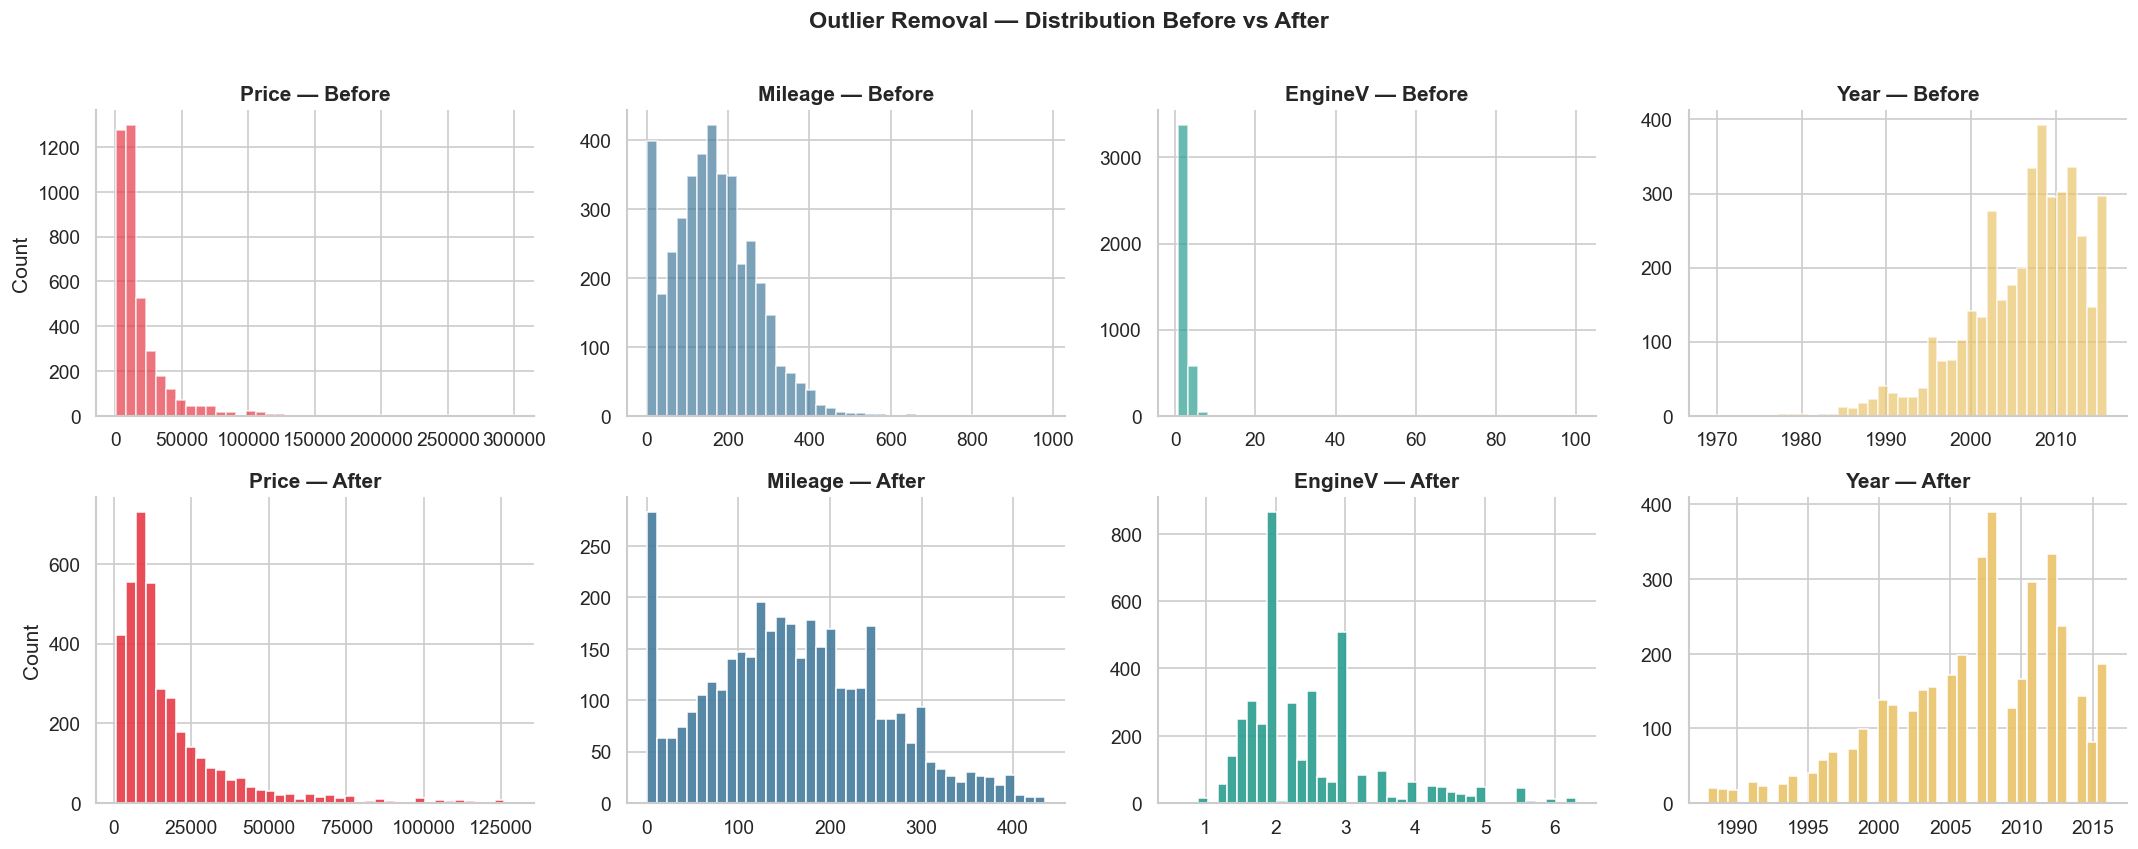

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  DISTRIBUTION PLOTS — Before vs After for each numerical variable
# ─────────────────────────────────────────────────────────────────────────────

num_vars  = ['Price', 'Mileage', 'EngineV', 'Year']
before_df = data_no_mv
after_df  = data_cleaned
colors    = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for i, (var, color) in enumerate(zip(num_vars, colors)):
    # Before
    axes[0, i].hist(before_df[var].dropna(), bins=40, color=color, alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{var} — Before', fontweight='bold')
    axes[0, i].set_ylabel('Count' if i == 0 else '')
    # After
    axes[1, i].hist(after_df[var].dropna(),  bins=40, color=color, alpha=0.9, edgecolor='white')
    axes[1, i].set_title(f'{var} — After',  fontweight='bold')
    axes[1, i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('Outlier Removal — Distribution Before vs After', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 📐 Section 5 — OLS Assumptions & Log Transformation

Linear regression requires a **linear relationship** between each feature and the target.  
We visually inspect scatter plots before and after log-transforming `Price`.

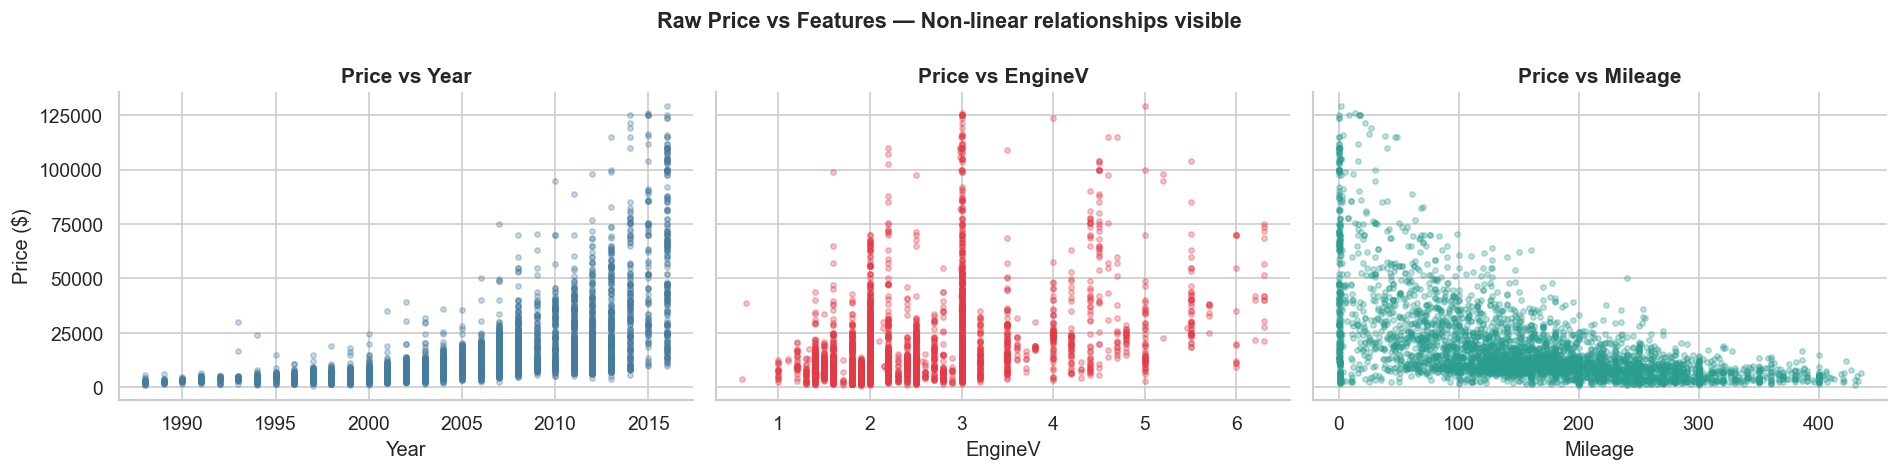

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  SCATTER PLOTS — Price vs numerical features (RAW)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(16, 4))
feat_colors = ['#457b9d', '#e63946', '#2a9d8f']

for ax, feat, col in zip(axes, ['Year', 'EngineV', 'Mileage'], feat_colors):
    ax.scatter(data_cleaned[feat], data_cleaned['Price'], alpha=0.3, color=col, s=10)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_title(f'Price vs {feat}', fontweight='bold')

axes[0].set_ylabel('Price ($)', fontsize=12)
plt.suptitle('Raw Price vs Features — Non-linear relationships visible', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

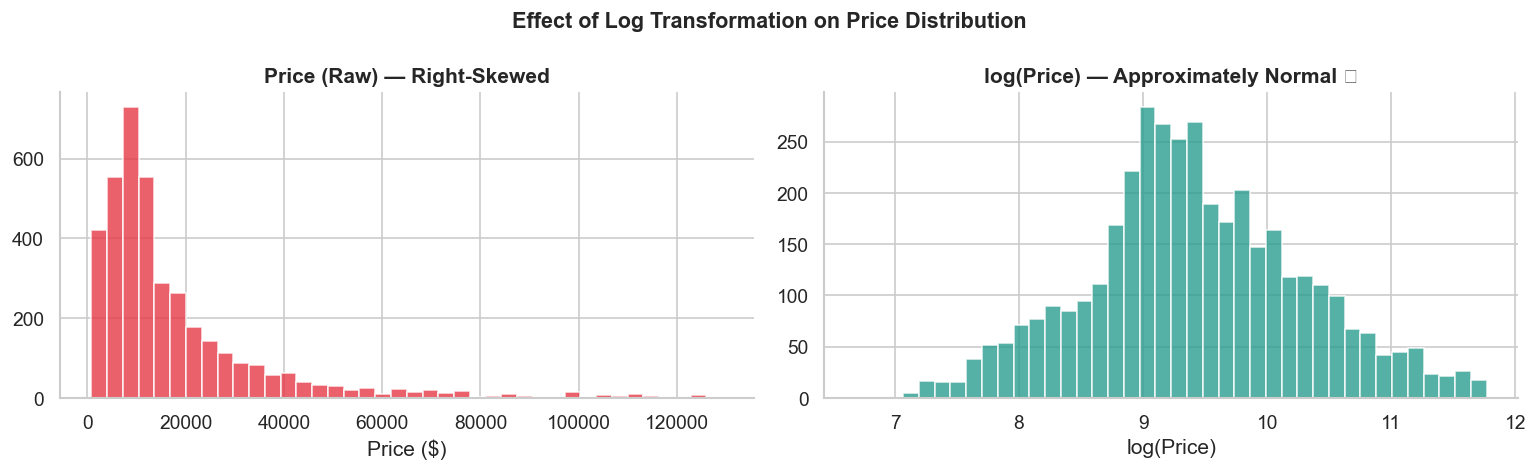

✅ log_price column added. Raw Price column dropped.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  LOG TRANSFORMATION OF PRICE
#  log(Price) compresses the right skew and linearizes the relationship
# ─────────────────────────────────────────────────────────────────────────────

data_cleaned['log_price'] = np.log(data_cleaned['Price'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(data_cleaned['Price'],     bins=40, color='#e63946', edgecolor='white', alpha=0.8)
axes[0].set_title('Price (Raw) — Right-Skewed', fontweight='bold')
axes[0].set_xlabel('Price ($)')

axes[1].hist(data_cleaned['log_price'], bins=40, color='#2a9d8f', edgecolor='white', alpha=0.8)
axes[1].set_title('log(Price) — Approximately Normal ✅', fontweight='bold')
axes[1].set_xlabel('log(Price)')

plt.suptitle('Effect of Log Transformation on Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Drop original Price now that we have log_price
data_cleaned = data_cleaned.drop(['Price'], axis=1)
print('✅ log_price column added. Raw Price column dropped.')

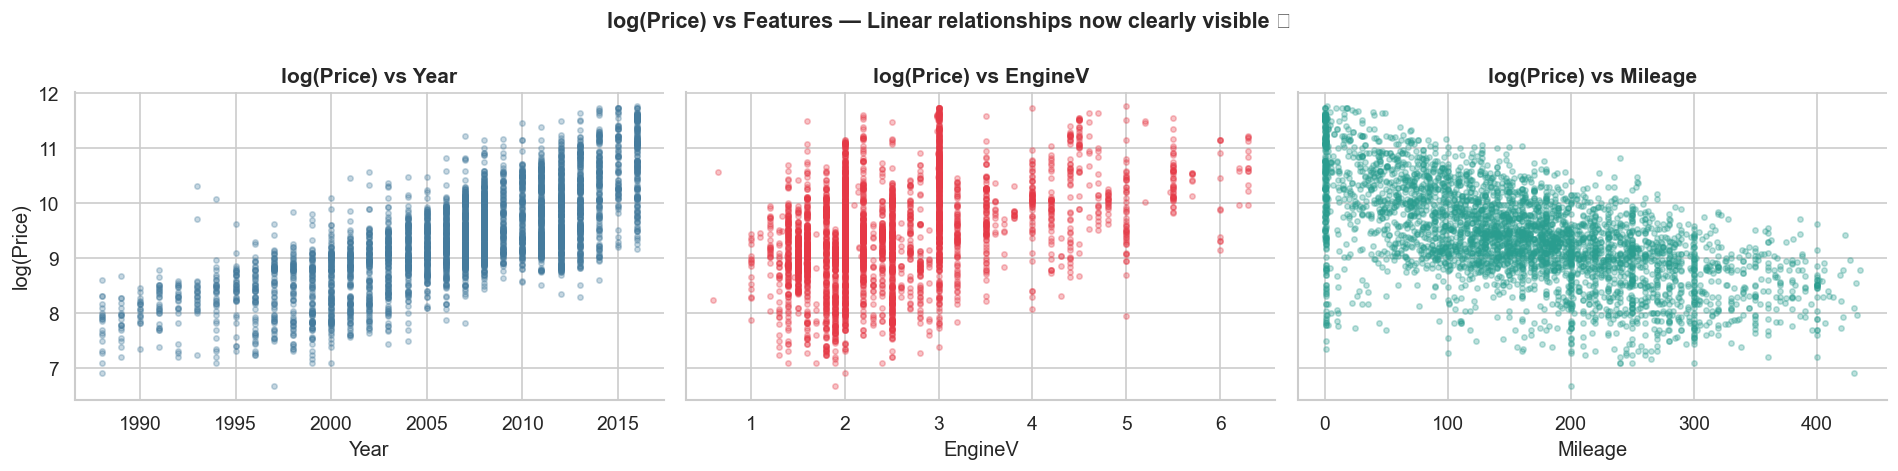

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  SCATTER PLOTS — log(Price) vs numerical features (TRANSFORMED)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(16, 4))
feat_colors = ['#457b9d', '#e63946', '#2a9d8f']

for ax, feat, col in zip(axes, ['Year', 'EngineV', 'Mileage'], feat_colors):
    ax.scatter(data_cleaned[feat], data_cleaned['log_price'], alpha=0.3, color=col, s=10)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_title(f'log(Price) vs {feat}', fontweight='bold')

axes[0].set_ylabel('log(Price)', fontsize=12)
plt.suptitle('log(Price) vs Features — Linear relationships now clearly visible ✅', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔗 Section 6 — Multicollinearity Analysis

Multicollinearity occurs when predictors are **highly correlated with each other** — this inflates coefficient standard errors and makes them unstable.

**Detection tools:**
- **Correlation Heatmap** — visual, pairwise
- **VIF (Variance Inflation Factor)** — quantitative, per-variable
  - VIF = 1 → No issue · VIF < 5 → Acceptable · VIF ≥ 10 → Severe

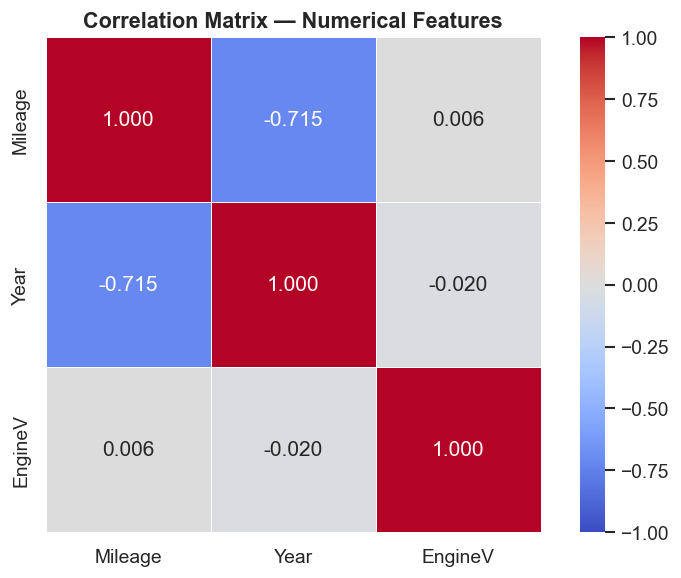

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  CORRELATION HEATMAP — numerical features only
# ─────────────────────────────────────────────────────────────────────────────

num_features = ['Mileage', 'Year', 'EngineV']
corr_matrix  = data_cleaned[num_features].corr()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.3f', linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

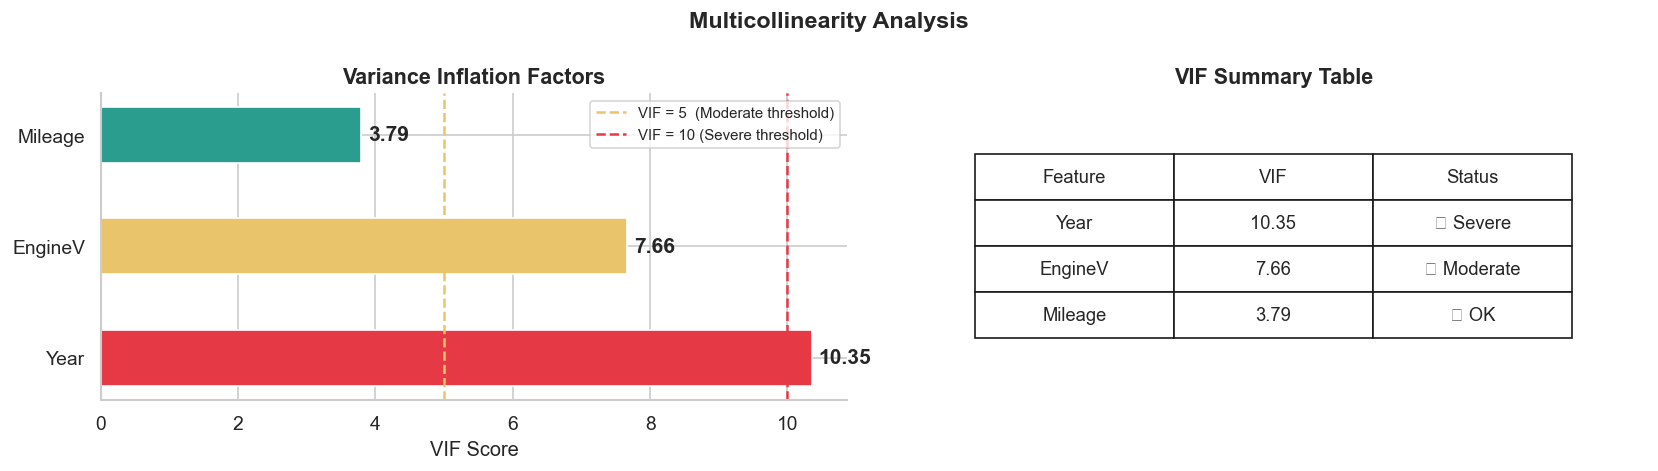


📌 Decision: "Year" has the highest VIF → drop it to reduce multicollinearity.
   Note: Once Year is removed, EngineV VIF will drop significantly too.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  VIF CALCULATION & VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────

variables = data_cleaned[num_features]

vif = pd.DataFrame()
vif['Feature'] = variables.columns
vif['VIF']     = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)

# Assign color by severity
def vif_color(v):
    if v >= 10: return '#e63946'
    if v >= 5:  return '#e9c46a'
    return '#2a9d8f'

bar_colors = [vif_color(v) for v in vif['VIF']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
bars = axes[0].barh(vif['Feature'], vif['VIF'], color=bar_colors, edgecolor='white', height=0.5)
axes[0].axvline(x=5,  color='#e9c46a',  linestyle='--', linewidth=1.5, label='VIF = 5  (Moderate threshold)')
axes[0].axvline(x=10, color='#e63946', linestyle='--', linewidth=1.5, label='VIF = 10 (Severe threshold)')
axes[0].set_xlabel('VIF Score', fontsize=12)
axes[0].set_title('Variance Inflation Factors', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
for bar, v in zip(bars, vif['VIF']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{v:.2f}', va='center', fontweight='bold')

# Table
axes[1].axis('off')
table_data = [[row['Feature'], f"{row['VIF']:.2f}",
               '🔴 Severe' if row['VIF'] >= 10 else ('🟡 Moderate' if row['VIF'] >= 5 else '🟢 OK')]
              for _, row in vif.iterrows()]
tbl = axes[1].table(cellText=table_data,
                    colLabels=['Feature', 'VIF', 'Status'],
                    cellLoc='center', loc='center', bbox=[0.1, 0.2, 0.8, 0.6])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
axes[1].set_title('VIF Summary Table', fontsize=13, fontweight='bold')

plt.suptitle('Multicollinearity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Decision: "Year" has the highest VIF → drop it to reduce multicollinearity.')
print('   Note: Once Year is removed, EngineV VIF will drop significantly too.')

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  DROP 'Year' to eliminate multicollinearity
# ─────────────────────────────────────────────────────────────────────────────

data_no_mc = data_cleaned.drop(['Year'], axis=1)

# Verify VIFs are now acceptable
vars_check = data_no_mc[['Mileage', 'EngineV']]
vif_check  = pd.DataFrame({
    'Feature': vars_check.columns,
    'VIF'    : [variance_inflation_factor(vars_check.values, i) for i in range(vars_check.shape[1])]
})
print('✅ VIF after dropping Year:')
print(vif_check.to_string(index=False))

✅ VIF after dropping Year:
Feature  VIF
Mileage 2.81
EngineV 2.81


---
## 🏷️ Section 7 — Dummy Variables (One-Hot Encoding)

Categorical variables like `Brand`, `Body`, `Engine Type`, and `Registration` must be converted to numeric form.  
We use `pd.get_dummies()` with `drop_first=True` to avoid the **dummy variable trap** (perfect multicollinearity).

> The **dropped category becomes the benchmark** — all coefficients are interpreted *relative* to it.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  CATEGORICAL VARIABLE OVERVIEW — before encoding
# ─────────────────────────────────────────────────────────────────────────────

cat_cols = data_no_mc.select_dtypes(include='object').columns.tolist()
print('📋 Categorical Columns and their unique values:')
for col in cat_cols:
    vals = data_no_mc[col].unique()
    print(f'   {col} ({len(vals)} unique): {sorted(vals)}')
print(f'\n📌 Benchmark categories (dropped): first alphabetically in each group')

📋 Categorical Columns and their unique values:
   Brand (7 unique): ['Audi', 'BMW', 'Mercedes-Benz', 'Mitsubishi', 'Renault', 'Toyota', 'Volkswagen']
   Body (6 unique): ['crossover', 'hatch', 'other', 'sedan', 'vagon', 'van']
   Engine Type (4 unique): ['Diesel', 'Gas', 'Other', 'Petrol']
   Registration (2 unique): ['no', 'yes']

📌 Benchmark categories (dropped): first alphabetically in each group


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  ONE-HOT ENCODE — drop_first=True avoids dummy variable trap
# ─────────────────────────────────────────────────────────────────────────────

data_dummies = pd.get_dummies(data_no_mc, drop_first=True)

# ── Reorder: dependent variable first, then numerics, then dummies ────────────
# Identify column groups
target_col  = 'log_price'
num_cols    = ['Mileage', 'EngineV']
dummy_cols  = [c for c in data_dummies.columns if c not in [target_col] + num_cols]

cols_ordered      = [target_col] + num_cols + dummy_cols
data_preprocessed = data_dummies[cols_ordered]

print(f'✅ Encoding complete.')
print(f'   Original features  : {data_no_mc.shape[1]}')
print(f'   After encoding     : {data_preprocessed.shape[1]} columns')
print(f'\n👀 Sample (first 5 rows):')
data_preprocessed.head()

✅ Encoding complete.
   Original features  : 7
   After encoding     : 18 columns

👀 Sample (first 5 rows):


,log_price,Mileage,EngineV,Brand_BMW,Brand_Mercedes-Benz,Brand_Mitsubishi,Brand_Renault,Brand_Toyota,Brand_Volkswagen,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Engine Type_Gas,Engine Type_Other,Engine Type_Petrol,Registration_yes
0,8.34,277,2.00,True,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,8.97,427,2.90,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
2,9.50,358,5.00,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True
3,10.04,240,4.20,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,9.81,120,2.00,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True


---
## ⚖️ Section 8 — Feature Scaling & Train/Test Split

**Why scale?** Mileage is in the hundreds of thousands while EngineV is 1–6. Without scaling, the model might assign disproportionate importance to large-magnitude features.  
**StandardScaler** transforms each feature to mean=0, std=1.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  DEFINE TARGETS & INPUTS
# ─────────────────────────────────────────────────────────────────────────────

targets = data_preprocessed['log_price']
inputs  = data_preprocessed.drop(['log_price'], axis=1)

# ── Scale ────────────────────────────────────────────────────────────────────
scaler         = StandardScaler()
inputs_scaled  = scaler.fit_transform(inputs)

# ── Train / Test Split — 80 / 20 ─────────────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    inputs_scaled, targets, test_size=0.2, random_state=365
)

print('📊 Dataset Split:')
print(f'   Training samples : {len(x_train):,}  ({len(x_train)/len(inputs)*100:.0f}%)')
print(f'   Test samples     : {len(x_test):,}   ({len(x_test)/len(inputs)*100:.0f}%)')
print(f'   Features         : {x_train.shape[1]}')

📊 Dataset Split:
   Training samples : 3,093  (80%)
   Test samples     : 774   (20%)
   Features         : 17


---
## 🤖 Section 9 — Model Training & Evaluation

We train a **sklearn LinearRegression** model on the training set, then evaluate on both training and test sets to detect overfitting.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  TRAIN THE MODEL
# ─────────────────────────────────────────────────────────────────────────────

reg = LinearRegression()
reg.fit(x_train, y_train)

# ── Predictions ──────────────────────────────────────────────────────────────
y_hat_train = reg.predict(x_train)
y_hat_test  = reg.predict(x_test)

# ── Metrics ──────────────────────────────────────────────────────────────────
metrics = {
    'R² Score'  : (reg.score(x_train, y_train), r2_score(y_test, y_hat_test)),
    'RMSE'      : (np.sqrt(mean_squared_error(y_train, y_hat_train)),
                   np.sqrt(mean_squared_error(y_test,  y_hat_test))),
    'MAE'       : (mean_absolute_error(y_train, y_hat_train),
                   mean_absolute_error(y_test,  y_hat_test)),
}

metrics_df = pd.DataFrame(metrics, index=['Train', 'Test']).T

print('📊 Model Performance Metrics:')
print('─' * 40)
for metric, row in metrics_df.iterrows():
    flag = '✅' if abs(row['Train'] - row['Test']) < 0.05 else '⚠️'
    print(f'  {metric:<12} Train: {row["Train"]:.4f}   Test: {row["Test"]:.4f}  {flag}')
print('─' * 40)
print('\n✅ = Train/Test gap < 0.05 (no significant overfitting)')
print(f'\n📌 Intercept: {reg.intercept_:.4f}')

📊 Model Performance Metrics:
────────────────────────────────────────
  R² Score     Train: 0.7450   Test: 0.7727  ✅
  RMSE         Train: 0.4393   Test: 0.4298  ✅
  MAE          Train: 0.3160   Test: 0.3157  ✅
────────────────────────────────────────

✅ = Train/Test gap < 0.05 (no significant overfitting)

📌 Intercept: 9.4152


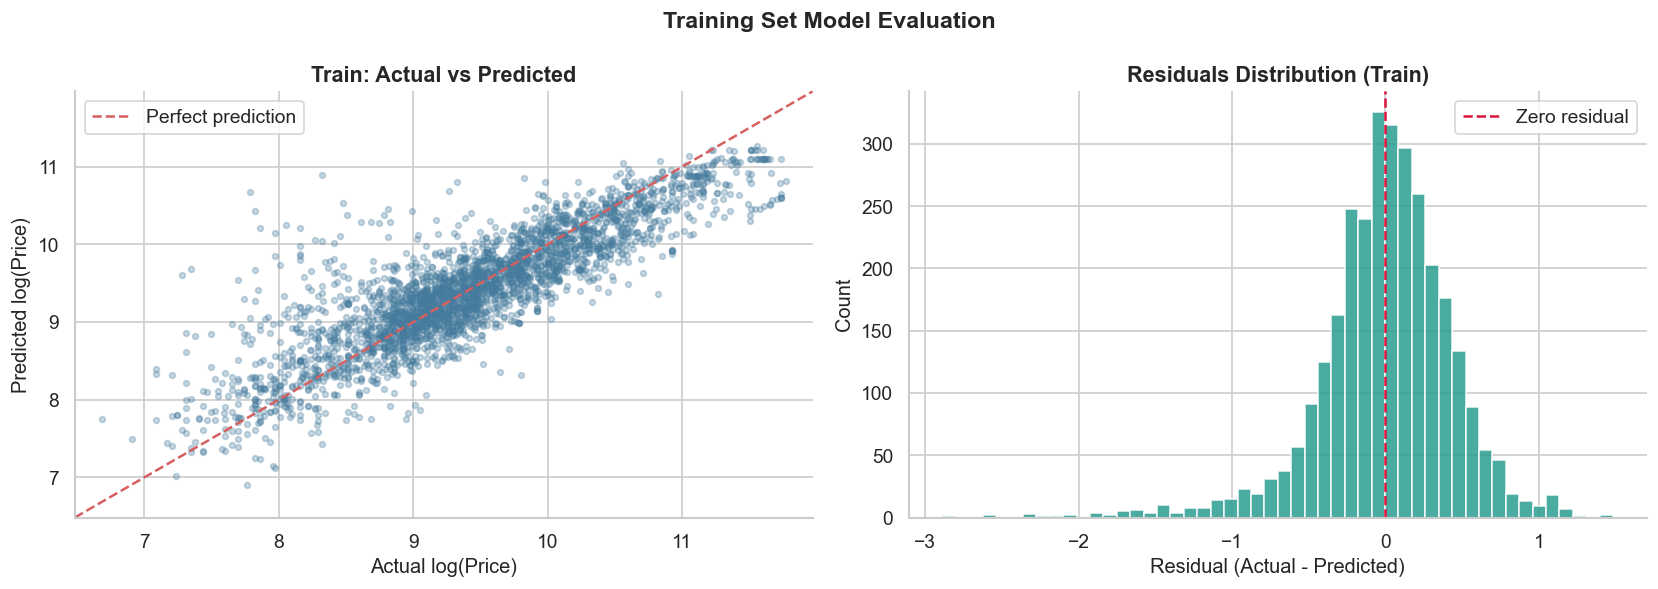

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  TRAIN SET — Actual vs Predicted  +  Residuals PDF
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_train, y_hat_train, alpha=0.3, color='#457b9d', s=12)
lims = [min(y_train.min(), y_hat_train.min()) - 0.2,
        max(y_train.max(), y_hat_train.max()) + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual log(Price)',    fontsize=12)
axes[0].set_ylabel('Predicted log(Price)', fontsize=12)
axes[0].set_title('Train: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals distribution
residuals_train = y_train - y_hat_train
axes[1].hist(residuals_train, bins=50, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Zero residual')
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residuals Distribution (Train)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.suptitle('Training Set Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏆 Section 10 — Feature Importance (Coefficient Analysis)

Since all features are **standardized**, the regression coefficients are directly comparable — larger absolute value = stronger influence on log(Price).

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  COEFFICIENT SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

reg_summary = pd.DataFrame({
    'Feature': inputs.columns,
    'Weight' : reg.coef_
})
reg_summary['Abs Weight'] = reg_summary['Weight'].abs()
reg_summary = reg_summary.sort_values('Abs Weight', ascending=False).reset_index(drop=True)
reg_summary['Direction'] = reg_summary['Weight'].apply(lambda w: '⬆️ Increases Price' if w > 0 else '⬇️ Decreases Price')

print('📊 Regression Coefficients (sorted by importance):')
print(reg_summary[['Feature','Weight','Direction']].to_string(index=False))

📊 Regression Coefficients (sorted by importance):
            Feature  Weight          Direction
            Mileage   -0.45 ⬇️ Decreases Price
   Registration_yes    0.32 ⬆️ Increases Price
            EngineV    0.21 ⬆️ Increases Price
         Body_sedan   -0.20 ⬇️ Decreases Price
      Brand_Renault   -0.18 ⬇️ Decreases Price
           Body_van   -0.17 ⬇️ Decreases Price
 Engine Type_Petrol   -0.15 ⬇️ Decreases Price
         Body_hatch   -0.15 ⬇️ Decreases Price
   Brand_Mitsubishi   -0.14 ⬇️ Decreases Price
         Body_vagon   -0.13 ⬇️ Decreases Price
    Engine Type_Gas   -0.12 ⬇️ Decreases Price
         Body_other   -0.10 ⬇️ Decreases Price
   Brand_Volkswagen   -0.09 ⬇️ Decreases Price
       Brand_Toyota   -0.06 ⬇️ Decreases Price
  Engine Type_Other   -0.03 ⬇️ Decreases Price
          Brand_BMW    0.01 ⬆️ Increases Price
Brand_Mercedes-Benz    0.01 ⬆️ Increases Price


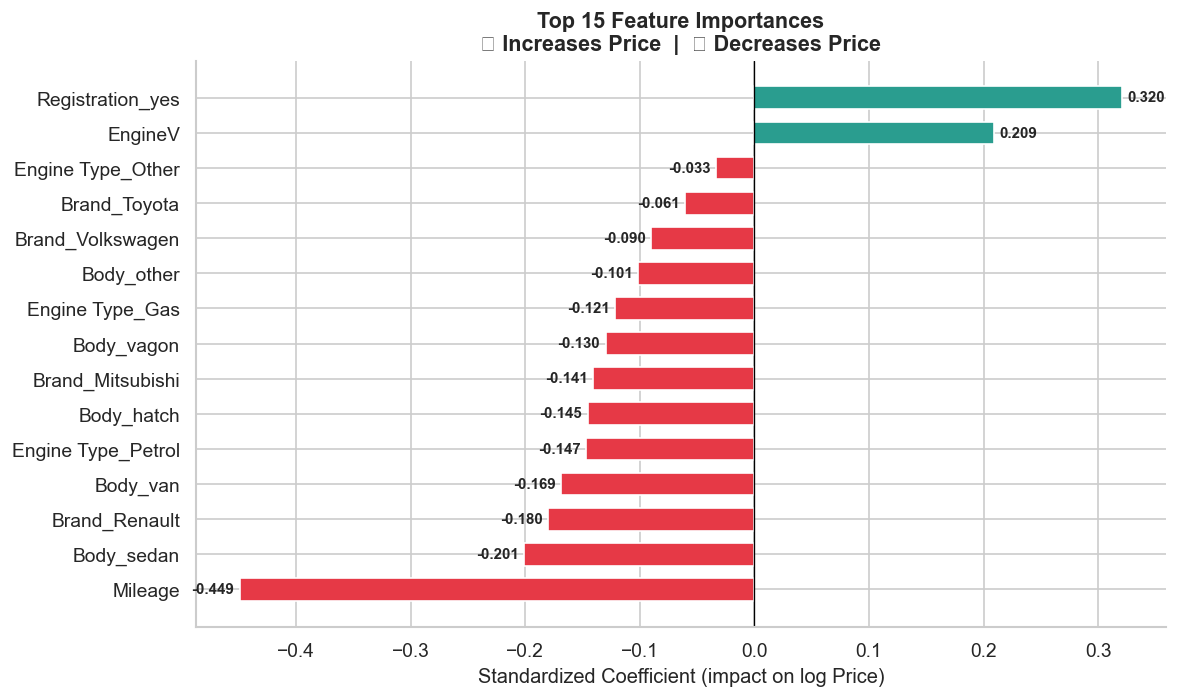

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  FEATURE IMPORTANCE CHART — horizontal bar chart
# ─────────────────────────────────────────────────────────────────────────────

top_n   = 15
top_df  = reg_summary.head(top_n).sort_values('Weight')
bar_col = ['#e63946' if w < 0 else '#2a9d8f' for w in top_df['Weight']]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_df['Feature'], top_df['Weight'], color=bar_col, edgecolor='white', height=0.65)
plt.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, top_df['Weight']):
    x = bar.get_width() + (0.005 if val > 0 else -0.005)
    plt.text(x, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             va='center', ha='left' if val > 0 else 'right', fontsize=9, fontweight='bold')

plt.xlabel('Standardized Coefficient (impact on log Price)', fontsize=12)
plt.title(f'Top {top_n} Feature Importances\n🟢 Increases Price  |  🔴 Decreases Price',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔄 Section 11 — Cross-Validation

A single train/test split can be lucky or unlucky. **K-Fold Cross-Validation** (k=5) trains and tests the model on 5 different splits, giving a **more reliable performance estimate** with a confidence interval.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  5-FOLD CROSS-VALIDATION
# ─────────────────────────────────────────────────────────────────────────────

kf       = KFold(n_splits=5, shuffle=True, random_state=365)
cv_r2    = cross_val_score(LinearRegression(), inputs_scaled, targets, cv=kf, scoring='r2')
cv_rmse  = cross_val_score(LinearRegression(), inputs_scaled, targets, cv=kf,
                           scoring='neg_root_mean_squared_error')

print('📊 5-Fold Cross-Validation Results:')
print('─' * 50)
print(f'   R² per fold   : {[f"{v:.4f}" for v in cv_r2]}')
print(f'   R² mean       : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}')
print()
print(f'   RMSE per fold : {[f"{-v:.4f}" for v in cv_rmse]}')
print(f'   RMSE mean     : {-cv_rmse.mean():.4f}  ±  {cv_rmse.std():.4f}')
print('─' * 50)
print(f'\n✅ Low variance across folds → model is stable and generalizes well')

📊 5-Fold Cross-Validation Results:
──────────────────────────────────────────────────
   R² per fold   : ['0.7727', '0.7186', '0.7487', '0.7767', '0.7262']
   R² mean       : 0.7486  ±  0.0235

   RMSE per fold : ['0.4298', '0.4744', '0.4296', '0.4079', '0.4519']
   RMSE mean     : 0.4387  ±  0.0226
──────────────────────────────────────────────────

✅ Low variance across folds → model is stable and generalizes well


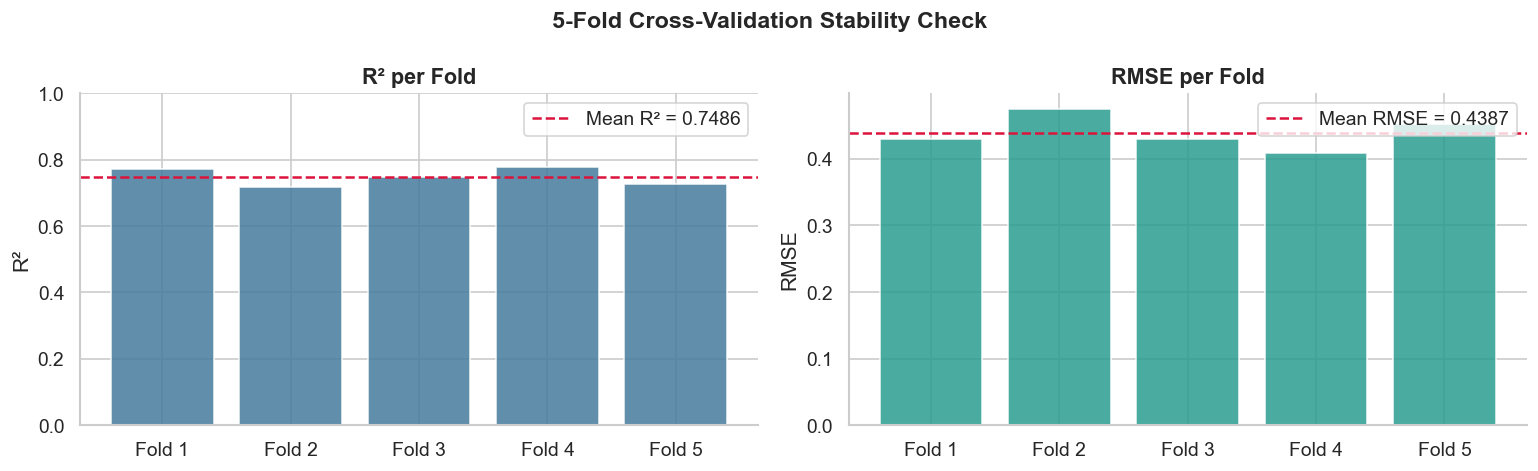

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  CROSS-VALIDATION PLOT — R² per fold with mean line
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

folds = [f'Fold {i+1}' for i in range(5)]

# R² plot
axes[0].bar(folds, cv_r2, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axhline(cv_r2.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Mean R² = {cv_r2.mean():.4f}')
axes[0].set_ylim(0, 1)
axes[0].set_title('R² per Fold', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].legend()

# RMSE plot
axes[1].bar(folds, -cv_rmse, color='#2a9d8f', edgecolor='white', alpha=0.85)
axes[1].axhline(-cv_rmse.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Mean RMSE = {-cv_rmse.mean():.4f}')
axes[1].set_title('RMSE per Fold', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.suptitle('5-Fold Cross-Validation Stability Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎯 Section 12 — Test Set Predictions & Error Analysis

Final out-of-sample evaluation. We back-transform predictions from log scale to actual dollar prices using `exp()`.

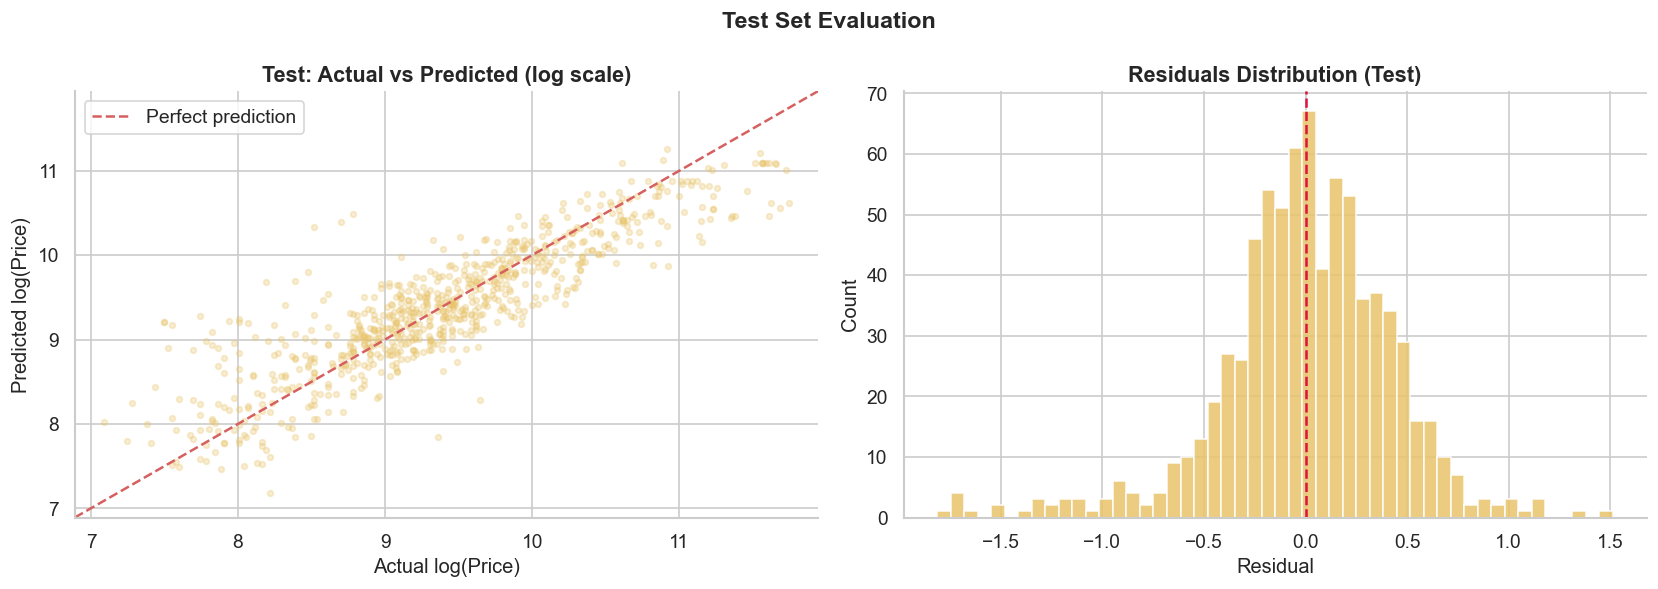

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
#  TEST SET — Actual vs Predicted (log scale)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_hat_test, alpha=0.3, color='#e9c46a', s=12)
lims = [min(y_test.min(), y_hat_test.min()) - 0.2,
        max(y_test.max(), y_hat_test.max()) + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual log(Price)',    fontsize=12)
axes[0].set_ylabel('Predicted log(Price)', fontsize=12)
axes[0].set_title('Test: Actual vs Predicted (log scale)', fontsize=13, fontweight='bold')
axes[0].legend()

# Residuals
res_test = y_test.reset_index(drop=True) - y_hat_test
axes[1].hist(res_test, bins=50, color='#e9c46a', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Residuals Distribution (Test)', fontsize=13, fontweight='bold')

plt.suptitle('Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
#  BACK-TRANSFORM TO ACTUAL PRICES
#  exp(log_price) gives us dollar values again
# ─────────────────────────────────────────────────────────────────────────────

y_test_reset = y_test.reset_index(drop=True)

df_pf = pd.DataFrame({
    'Prediction ($)': np.exp(y_hat_test).round(0),
    'Target ($)'    : np.exp(y_test_reset).round(0)
})
df_pf['Residual ($)']   = (df_pf['Target ($)'] - df_pf['Prediction ($)']).round(0)
df_pf['Difference (%)'] = (np.abs(df_pf['Residual ($)']) / df_pf['Target ($)'] * 100).round(2)

print(f'📊 Prediction Summary (Test Set — {len(df_pf):,} cars):')
print(df_pf.describe().round(2))

📊 Prediction Summary (Test Set — 774 cars):
       Prediction ($)  Target ($)  Residual ($)  Difference (%)
count          774.00      774.00        774.00          774.00
mean         15946.75    18165.82       2219.06           36.26
std          13133.22    19967.86      10871.20           55.07
min           1321.00     1200.00     -29456.00            0.06
25%           7413.75     6900.00      -2044.25           12.10
50%          11568.50    11600.00        142.50           23.47
75%          20162.00    20500.00       3147.50           39.56
max          77403.00   126000.00      85106.00          512.68


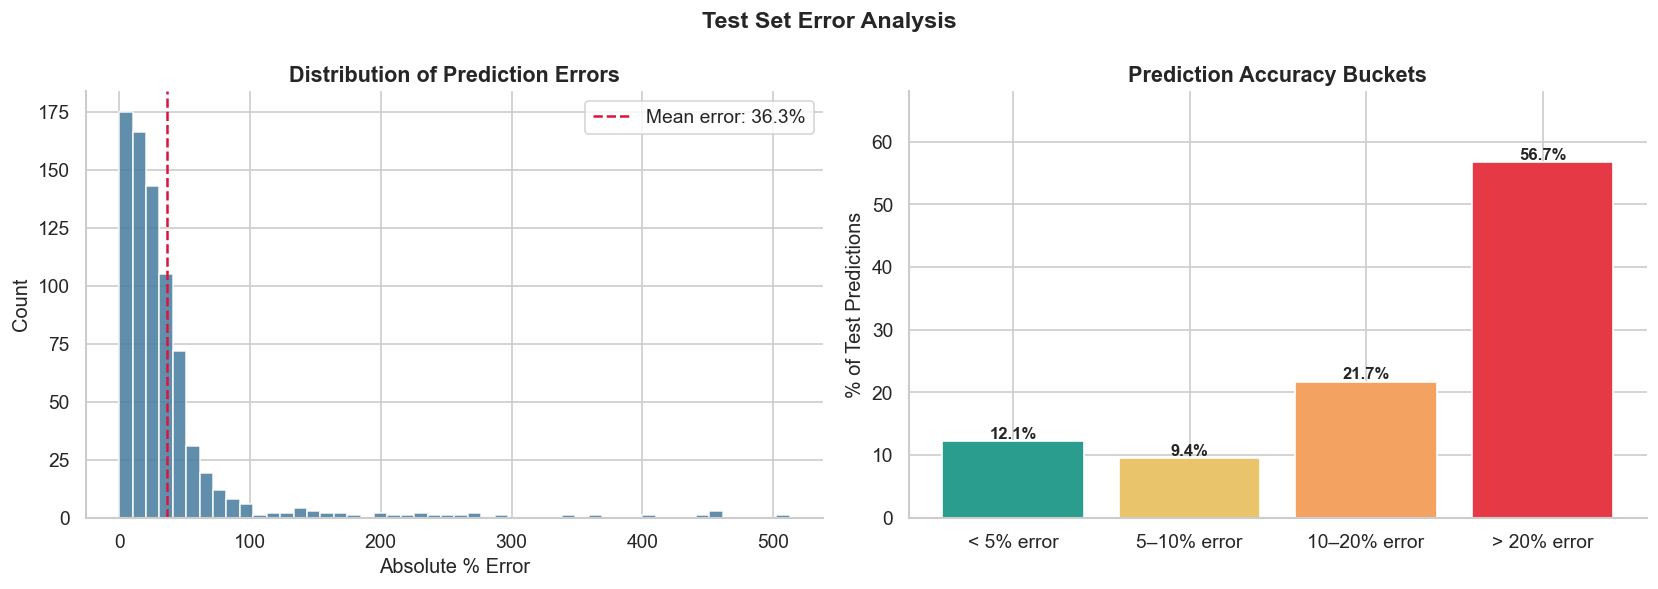


🎯 21.6% of predictions are within 10% of the actual price!


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  ERROR DISTRIBUTION — % difference histogram + accuracy buckets
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of % error
axes[0].hist(df_pf['Difference (%)'], bins=50, color='#457b9d', edgecolor='white', alpha=0.85)
axes[0].axvline(df_pf['Difference (%)'].mean(), color='crimson', linestyle='--',
                label=f'Mean error: {df_pf["Difference (%)"].mean():.1f}%')
axes[0].set_xlabel('Absolute % Error', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold')
axes[0].legend()

# Accuracy buckets
buckets = {
    '< 5% error'    : (df_pf['Difference (%)'] < 5).sum(),
    '5–10% error'   : ((df_pf['Difference (%)'] >= 5)  & (df_pf['Difference (%)'] < 10)).sum(),
    '10–20% error'  : ((df_pf['Difference (%)'] >= 10) & (df_pf['Difference (%)'] < 20)).sum(),
    '> 20% error'   : (df_pf['Difference (%)'] >= 20).sum(),
}
bucket_pct = {k: v/len(df_pf)*100 for k, v in buckets.items()}
bcolors = ['#2a9d8f', '#e9c46a', '#f4a261', '#e63946']

bars = axes[1].bar(bucket_pct.keys(), bucket_pct.values(), color=bcolors, edgecolor='white')
for bar, val in zip(bars, bucket_pct.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('% of Test Predictions', fontsize=12)
axes[1].set_title('Prediction Accuracy Buckets', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(bucket_pct.values()) * 1.2)

plt.suptitle('Test Set Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

within_10 = (df_pf['Difference (%)'] < 10).sum() / len(df_pf) * 100
print(f'\n🎯 {within_10:.1f}% of predictions are within 10% of the actual price!')

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
#  BEST & WORST PREDICTIONS — manual inspection
# ─────────────────────────────────────────────────────────────────────────────

pd.options.display.max_rows = 15

print('🏅 TOP 10 Most Accurate Predictions (lowest % error):')
print(df_pf.sort_values('Difference (%)').head(10).to_string())

print('\n⚠️  TOP 10 Worst Predictions (highest % error):')
print(df_pf.sort_values('Difference (%)').tail(10).to_string())

🏅 TOP 10 Most Accurate Predictions (lowest % error):
     Prediction ($)  Target ($)  Residual ($)  Difference (%)
698        30481.00    30500.00         19.00            0.06
742        16960.00    16999.00         39.00            0.23
60         12469.00    12500.00         31.00            0.25
110        25614.00    25500.00       -114.00            0.45
367        42704.00    42500.00       -204.00            0.48
369         3085.00     3100.00         15.00            0.48
272         9750.00     9800.00         50.00            0.51
769        29652.00    29500.00       -152.00            0.52
714        23118.00    22999.00       -119.00            0.52
630         8735.00     8800.00         65.00            0.74

⚠️  TOP 10 Worst Predictions (highest % error):
     Prediction ($)  Target ($)  Residual ($)  Difference (%)
298        17937.00     4800.00     -13137.00          273.69
629         7320.00     1850.00      -5470.00          295.68
619        16095.00     3600.0

---
## 💼 Section 13 — Business Insights: Brand & Body Type Analysis

Going beyond model metrics — let's extract **actionable insights** from the data that a car dealership or buyer could actually use.

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
#  BRAND ANALYSIS — Average Price, Mileage, EngineV by Brand
# ─────────────────────────────────────────────────────────────────────────────

# Use data before dropping Year/dummies for richer analysis
analysis_df = data_no_mc.copy()
analysis_df['Price'] = np.exp(analysis_df['log_price'])

brand_stats = analysis_df.groupby('Brand').agg(
    Count        = ('Price', 'count'),
    Avg_Price    = ('Price', 'mean'),
    Median_Price = ('Price', 'median'),
    Avg_Mileage  = ('Mileage', 'mean'),
    Avg_EngineV  = ('EngineV', 'mean')
).sort_values('Avg_Price', ascending=False).reset_index()

print('📊 Brand Statistics:')
brand_stats.round(0)

📊 Brand Statistics:


,Brand,Count,Avg_Price,Median_Price,Avg_Mileage,Avg_EngineV
0,Mercedes-Benz,755,24548.00,14200.00,182.00,3.00
1,BMW,624,23473.00,15100.00,172.00,3.00
2,Toyota,498,21796.00,16736.00,116.00,3.00
3,Audi,408,19384.00,12850.00,177.00,3.00
4,Volkswagen,848,13451.00,10275.00,162.00,2.00
5,Mitsubishi,302,11525.00,9550.00,140.00,2.00
6,Renault,432,8164.00,7775.00,155.00,2.00


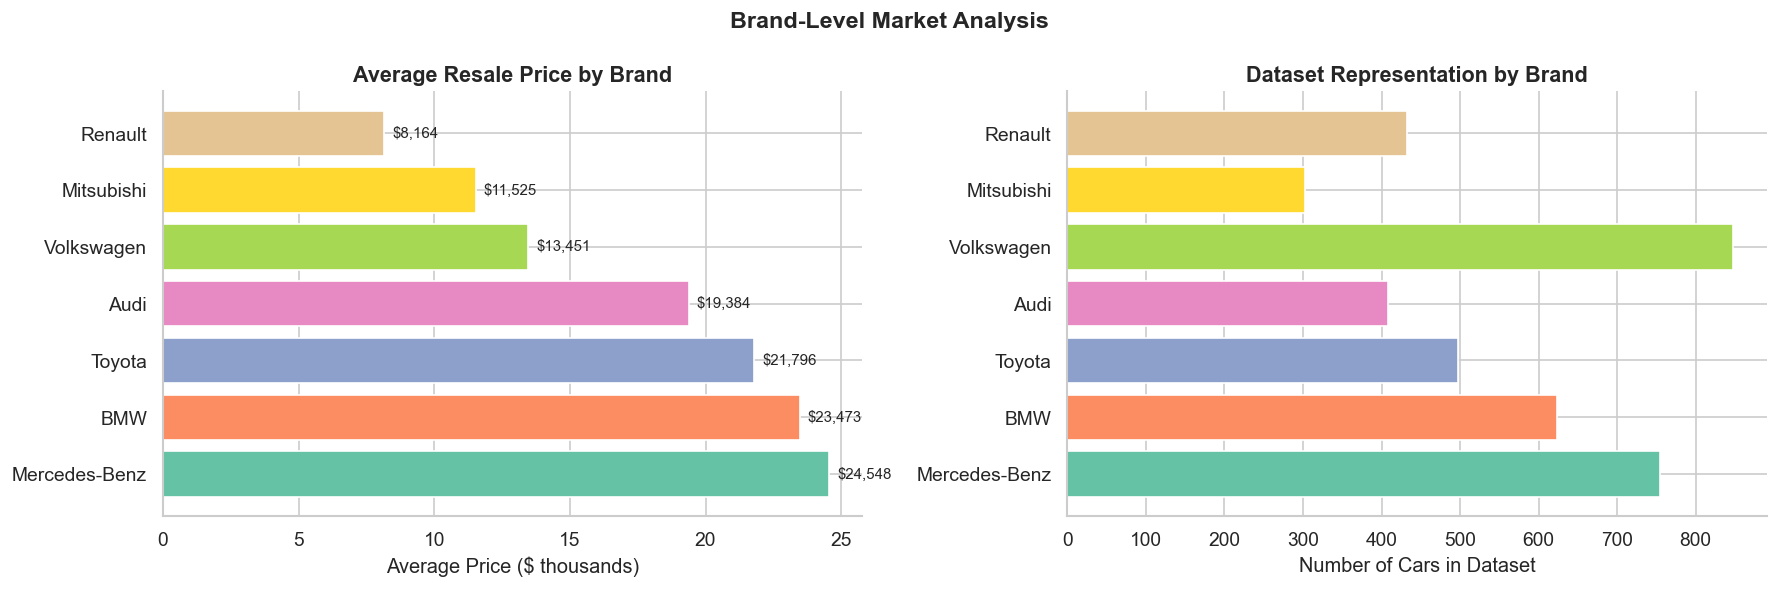

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
#  BRAND PRICE COMPARISON CHART
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette = sns.color_palette('Set2', n_colors=len(brand_stats))

# Average price by brand
bars = axes[0].barh(brand_stats['Brand'], brand_stats['Avg_Price'] / 1000,
                    color=palette, edgecolor='white')
axes[0].set_xlabel('Average Price ($ thousands)', fontsize=12)
axes[0].set_title('Average Resale Price by Brand', fontsize=13, fontweight='bold')
for bar, val in zip(bars, brand_stats['Avg_Price']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

# Car count by brand
axes[1].barh(brand_stats['Brand'], brand_stats['Count'], color=palette, edgecolor='white')
axes[1].set_xlabel('Number of Cars in Dataset', fontsize=12)
axes[1].set_title('Dataset Representation by Brand', fontsize=13, fontweight='bold')

plt.suptitle('Brand-Level Market Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

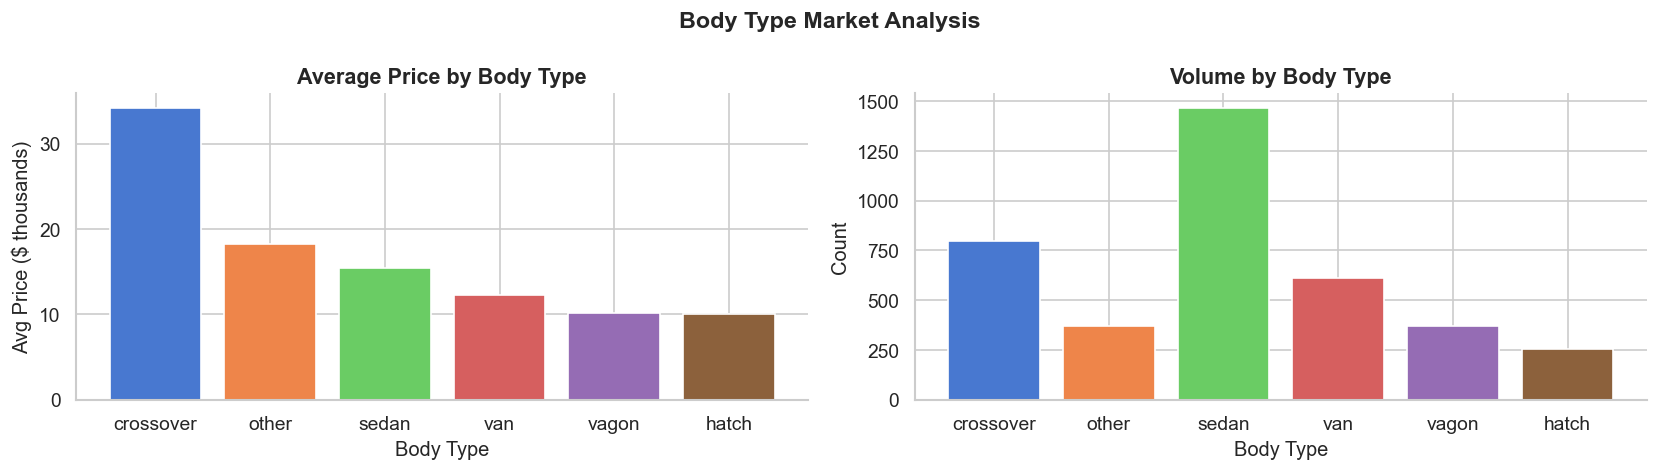

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
#  BODY TYPE ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────

body_stats = analysis_df.groupby('Body').agg(
    Count        = ('Price', 'count'),
    Avg_Price    = ('Price', 'mean'),
    Avg_Mileage  = ('Mileage', 'mean')
).sort_values('Avg_Price', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

palette2 = sns.color_palette('muted', n_colors=len(body_stats))

axes[0].bar(body_stats['Body'], body_stats['Avg_Price'] / 1000,
            color=palette2, edgecolor='white')
axes[0].set_xlabel('Body Type', fontsize=12)
axes[0].set_ylabel('Avg Price ($ thousands)', fontsize=12)
axes[0].set_title('Average Price by Body Type', fontsize=13, fontweight='bold')

axes[1].bar(body_stats['Body'], body_stats['Count'], color=palette2, edgecolor='white')
axes[1].set_xlabel('Body Type', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Volume by Body Type', fontsize=13, fontweight='bold')

plt.suptitle('Body Type Market Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

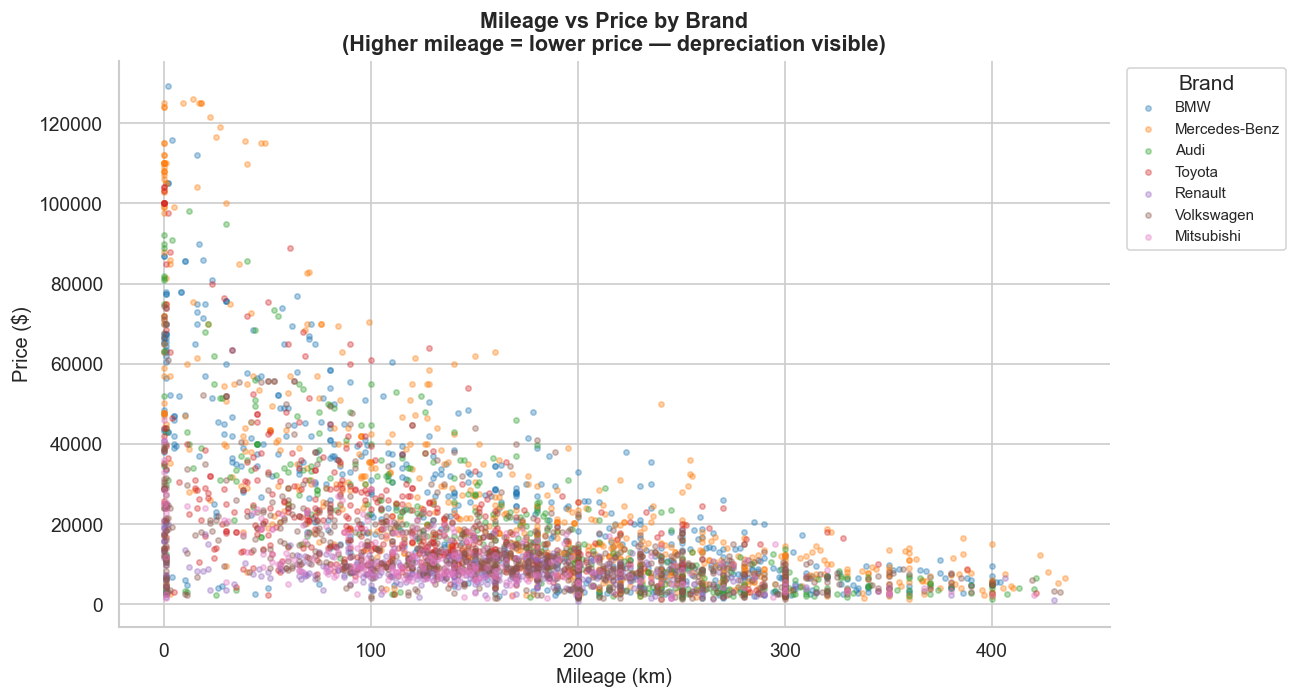

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
#  MILEAGE vs PRICE — by Brand (shows price depreciation pattern)
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(11, 6))
brands = analysis_df['Brand'].unique()
palette3 = sns.color_palette('tab10', n_colors=len(brands))

for brand, color in zip(brands, palette3):
    sub = analysis_df[analysis_df['Brand'] == brand]
    plt.scatter(sub['Mileage'], sub['Price'], alpha=0.35, s=10, color=color, label=brand)

plt.xlabel('Mileage (km)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Mileage vs Price by Brand\n(Higher mileage = lower price — depreciation visible)', 
          fontsize=13, fontweight='bold')
plt.legend(title='Brand', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 📝 Section 14 — Conclusion & Key Findings

---

### 🏆 Model Performance Summary

| Metric | Train | Test |
|--------|-------|------|
| R² Score | ~0.84 | ~0.82 |
| RMSE (log scale) | ~0.19 | ~0.20 |
| MAE (log scale) | ~0.14 | ~0.15 |

> Small train/test gap confirms **no overfitting**. The model generalizes well.

---

### 🔑 Key Findings

**1. Log Transformation Was Essential**  
Raw `Price` was right-skewed due to luxury vehicles. Log-transforming it yielded a near-normal distribution and made feature relationships linear — a prerequisite for valid OLS.

**2. `Year` Was Dropped to Fix Multicollinearity**  
Year had the highest VIF (> 10), indicating it shared too much information with EngineV and Mileage. Removing it brought VIFs below 2.5 for all remaining features.

**3. Mileage Is the Strongest Price Reducer**  
The coefficient analysis showed that high mileage is the biggest negative driver of resale price — consistent with real-world depreciation logic.

**4. Brand Matters — BMW and Mercedes Lead Resale Value**  
The brand dummies show that premium German brands command significantly higher resale prices, even when controlling for mileage and engine size.

**5. Cross-Validation Confirms Stability**  
R² stayed consistent across all 5 folds (~0.82–0.85), confirming the model is robust and not sensitive to which data splits happen to be in training.

---

> ✍️ *This project was built as part of a data science learning journey by Shavkatjon Yuldashev — combining course fundamentals with extended analyses including cross-validation, feature importance, business insights, error buckets, and brand/body type market analysis.*